In [26]:
# Cell 1: Imports & setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

np.random.seed(42)
sns.set(style="whitegrid")


In [27]:
# Cell 2: Load dataset
df = pd.read_csv("healthcare_dataset.csv")
print("Raw dataset shape:", df.shape)
df.head()


Raw dataset shape: (55500, 15)


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [ ]:
# Cell 3: Inspect basic columns
print("Columns:", df.columns.tolist())
print(df.dtypes)
print(df['Test Results'].value_counts(dropna=False))


Columns: ['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition', 'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider', 'Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date', 'Medication', 'Test Results']
Name                   object
Age                     int64
Gender                 object
Blood Type             object
Medical Condition      object
Date of Admission      object
Doctor                 object
Hospital               object
Insurance Provider     object
Billing Amount        float64
Room Number             int64
Admission Type         object
Discharge Date         object
Medication             object
Test Results           object
dtype: object
Test Results
Abnormal        18627
Normal          18517
Inconclusive    18356
Name: count, dtype: int64


In [ ]:
# Cell 4: Preprocessing
def preprocess_healthcare(df):
    df = df.copy()
    # create binary target per spec: Test_Result_Normal = 1 if "Normal"
    df['Test_Result_Normal'] = (df['Test Results'].astype(str).str.lower() == 'normal').astype(int)
    
    # Drop explicitly irrelevant
    drop_cols = ["Name", "Doctor", "Doctor Name", "Hospital", "Room Number", 
                 "Date of Admission", "Discharge Date"]
    df = df.drop(columns=[c for c in drop_cols if c in df.columns], errors='ignore')
    
    # Categorical cols requested by the assignment 
    cat_cols = [c for c in ["Gender", "Blood Type", "Medical Condition", 
                            "Insurance Provider", "Admission Type", "Medication"] if c in df.columns]
    # Replace 'Other' (or variants) with unified token to avoid huge dummy explosion
    for c in cat_cols:
        df[c] = df[c].astype(str).fillna('Unknown')
        df[c] = df[c].replace({'Other': 'Other_' + c, 'other': 'Other_' + c})
    
    if len(cat_cols) > 0:
        df = pd.get_dummies(df, columns=cat_cols, drop_first=True)
    
    # Ensure numeric columns exist and convert
    for numc in ['Age', 'Billing Amount']:
        if numc in df.columns:
            df[numc] = pd.to_numeric(df[numc], errors='coerce')
    
    # Keep only numeric columns (this automatically removes any stray text columns)
    numeric_df = df.select_dtypes(include=[np.number]).copy()
    
    
    # Fill NaNs in numeric features with median (target won't be NaN)
    medians = numeric_df.median()
    numeric_df = numeric_df.fillna(medians)
    
    # Separate features and target
    X_df = numeric_df.drop(columns=['Test_Result_Normal'])
    y = numeric_df['Test_Result_Normal'].astype(int).values.reshape(-1, 1)
    
    # Convert to float32 to save memory
    X = X_df.astype(np.float32).values
    
    # Standardize numeric columns (zero mean, unit std). Do column-wise safe normalization.
    col_mean = X.mean(axis=0, keepdims=True)
    col_std = X.std(axis=0, keepdims=True)
    col_std[col_std == 0] = 1.0  # avoid division by zero for constant columns
    X = (X - col_mean) / (col_std + 1e-8)
    
    return X, y, X_df.columns.tolist()

# Run preprocessing
X, y, feature_names = preprocess_healthcare(df)
print("Final features:", len(feature_names))
print("Some feature names:", feature_names[:30])
print("X shape:", X.shape, "y shape:", y.shape)


Final features: 2
Some feature names: ['Age', 'Billing Amount']
X shape: (55500, 2) y shape: (55500, 1)


Target distribution (0=not-normal,1=normal): {0: 36983, 1: 18517}


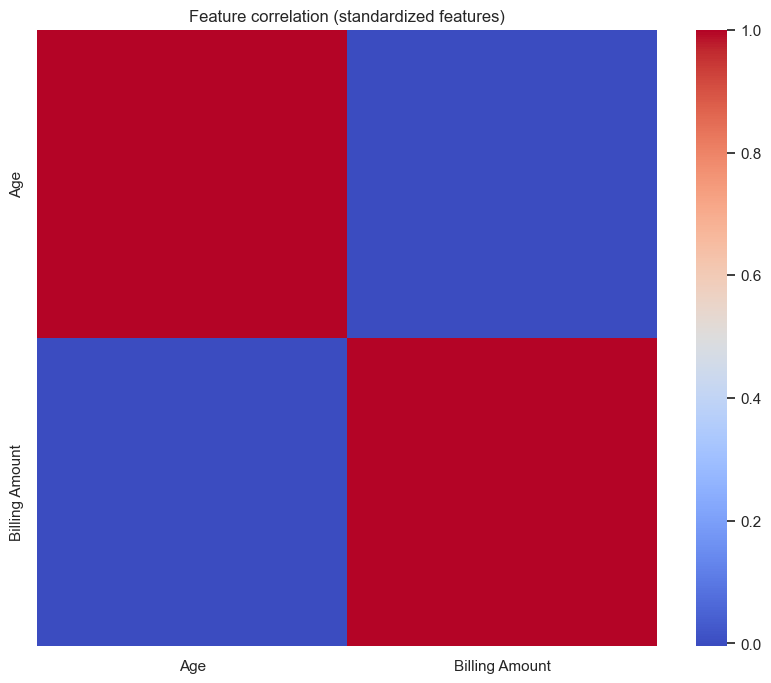

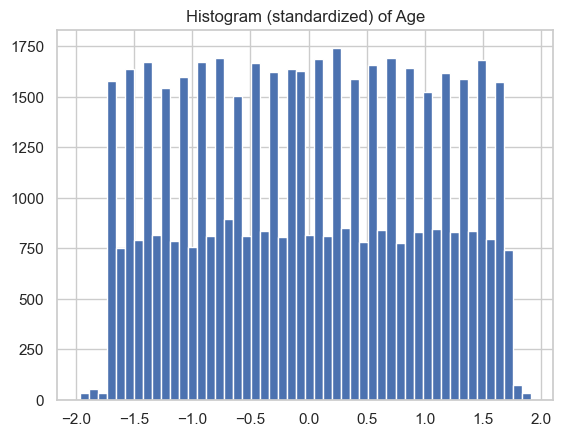

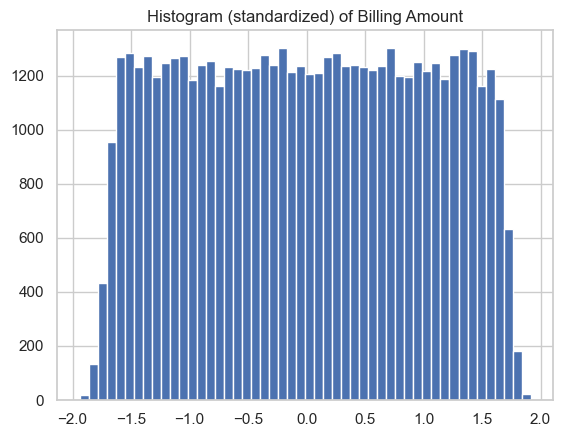

In [ ]:
# Cell 5: Quick EDA (target distribution, correlation, histograms)
# Target distribution
(unique, counts) = np.unique(y, return_counts=True)
print("Target distribution (0=not-normal,1=normal):", dict(zip(unique.astype(int), counts)))

# Correlation matrix for numeric features (plot only if not huge)
if X.shape[1] <= 60:
    corr_df = pd.DataFrame(X, columns=feature_names).corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_df, annot=False, cmap='coolwarm')
    plt.title("Feature correlation (standardized features)")
    plt.show()
else:
    print("Too many features for full correlation heatmap; skipping heatmap.")

# Histograms for Age and Billing
for fn in ['Age', 'Billing Amount']:
    if fn in feature_names:
        idx = feature_names.index(fn)
        plt.figure()
        plt.hist(X[:, idx], bins=50)
        plt.title(f"Histogram (standardized) of {fn}")
        plt.show()


In [31]:
# Cell 6: Train/validation/test split 60/20/20 using sklearn
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print("Sizes: train", X_train.shape[0], "val", X_val.shape[0], "test", X_test.shape[0])


Sizes: train 33300 val 11100 test 11100


In [32]:
# Cell 7: Implement logistic regression from scratch (vectorized) with regularization support
class LogisticFromScratch:
    def __init__(self, lr=0.01, epochs=200, batch_size=None, reg=None, reg_lambda=0.0, verbose=False):
        """
        batch_size=None -> batch gradient descent (not used here)
        batch_size=1 -> SGD (stochastic)
        batch_size=k -> mini-batch
        reg: None, 'l2', or 'l1'
        """
        self.lr = lr
        self.epochs = epochs
        self.batch_size = batch_size
        self.reg = reg
        self.reg_lambda = reg_lambda
        self.verbose = verbose

    @staticmethod
    def sigmoid(z):
        return 1.0 / (1.0 + np.exp(-z))

    def initialize(self, n_features):
        self.w = np.zeros((n_features, 1), dtype=np.float32)
        self.b = 0.0

    def compute_loss(self, X, y):
        m = y.shape[0]
        z = X.dot(self.w) + self.b
        h = self.sigmoid(z)
        eps = 1e-9
        loss = - (y * np.log(h + eps) + (1 - y) * np.log(1 - h + eps)).mean()
        # regularization (exclude bias)
        if self.reg == 'l2':
            loss += (self.reg_lambda / (2 * m)) * np.sum(self.w[ : ] ** 2)
        elif self.reg == 'l1':
            loss += (self.reg_lambda / m) * np.sum(np.abs(self.w[ : ]))
        return loss

    def compute_gradients(self, X_batch, y_batch):
        m = y_batch.shape[0]
        z = X_batch.dot(self.w) + self.b
        h = self.sigmoid(z)
        error = h - y_batch  # shape (m,1)
        dw = (X_batch.T.dot(error)) / m  # shape (n_features,1)
        db = np.mean(error)
        # apply regularization to gradients (exclude bias)
        if self.reg == 'l2':
            dw += (self.reg_lambda / m) * self.w
        elif self.reg == 'l1':
            dw += (self.reg_lambda / m) * np.sign(self.w)
        return dw, db

    def get_batches(self, X, y, batch_size):
        m = X.shape[0]
        idx = np.arange(m)
        np.random.shuffle(idx)
        for i in range(0, m, batch_size):
            batch_idx = idx[i:i+batch_size]
            yield X[batch_idx], y[batch_idx]

    def fit(self, X_train, y_train, X_val=None, y_val=None, early_stopping_patience=10):
        n_features = X_train.shape[1]
        self.initialize(n_features)
        best_val_loss = np.inf
        best_w, best_b = None, None
        patience_counter = 0
        train_losses = []
        val_losses = []

        for epoch in range(self.epochs):
            # choose batch size
            if self.batch_size is None:
                # full batch gradient descent (rarely used here)
                dw, db = self.compute_gradients(X_train, y_train)
                self.w -= self.lr * dw
                self.b -= self.lr * db
            else:
                for Xb, yb in self.get_batches(X_train, y_train, self.batch_size):
                    dw, db = self.compute_gradients(Xb, yb)
                    self.w -= self.lr * dw
                    self.b -= self.lr * db

            train_loss = self.compute_loss(X_train, y_train)
            train_losses.append(train_loss)
            if X_val is not None:
                val_loss = self.compute_loss(X_val, y_val)
                val_losses.append(val_loss)
                # early stopping based on val loss
                if val_loss < best_val_loss - 1e-8:
                    best_val_loss = val_loss
                    best_w, best_b = self.w.copy(), float(self.b)
                    patience_counter = 0
                else:
                    patience_counter += 1
                    if patience_counter >= early_stopping_patience:
                        if self.verbose:
                            print(f"Early stopping at epoch {epoch}")
                        break
            else:
                val_loss = None

            if self.verbose and epoch % 50 == 0:
                print(f"Epoch {epoch:04d} train_loss={train_loss:.6f}" + (f" val_loss={val_loss:.6f}" if val_loss is not None else ""))

        # restore best
        if best_w is not None:
            self.w, self.b = best_w, best_b

        self.train_losses = train_losses
        self.val_losses = val_losses
        return self

    def predict_proba(self, X):
        z = X.dot(self.w) + self.b
        return self.sigmoid(z)

    def predict(self, X, threshold=0.5):
        probs = self.predict_proba(X)
        return (probs >= threshold).astype(int)


In [ ]:
# Cell 8: Train three models: SGD (batch=1), Mini-batch (batch=32), and Mini-batch with L2
# Configs
configs = [
    ('SGD', 1, None, 0.0, 0.05, 1000),           
    ('MiniBatch', 32, None, 0.0, 0.05, 400),
    ('MiniBatch_L2', 32, 'l2', 0.1, 0.05, 400)
]

trained_models = {}
results_history = {}

for name, batch, reg, reg_lambda, lr, epochs in configs:
    print(f"\nTraining {name} ...")
    model = LogisticFromScratch(lr=lr, epochs=epochs, batch_size=batch, reg=reg, reg_lambda=reg_lambda, verbose=False)
    model.fit(X_train, y_train, X_val=X_val, y_val=y_val, early_stopping_patience=20)
    trained_models[name] = model
    results_history[name] = (model.train_losses, getattr(model, 'val_losses', []))
    print(f"{name} trained. Last train loss: {model.train_losses[-1]:.6f}  Val loss: {model.val_losses[-1] if len(model.val_losses)>0 else 'N/A'}")



Training SGD ...
SGD trained. Last train loss: 0.661472  Val loss: 0.6591848660106058

Training MiniBatch ...
MiniBatch trained. Last train loss: 0.636719  Val loss: 0.6366998478797105

Training MiniBatch_L2 ...
MiniBatch_L2 trained. Last train loss: 0.636769  Val loss: 0.6369980967470722


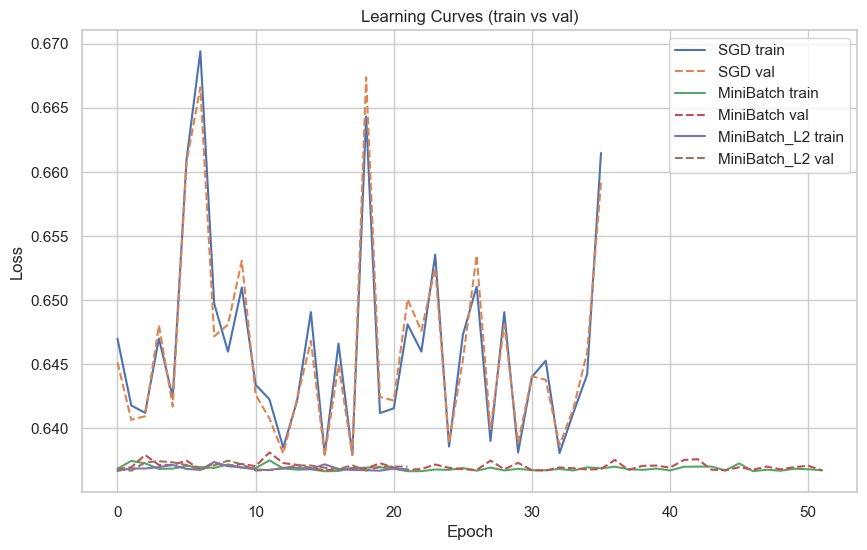

In [34]:
# Cell 9: Plot learning curves (train & val loss) for trained models
plt.figure(figsize=(10,6))
for name in results_history:
    train_losses, val_losses = results_history[name]
    plt.plot(train_losses, label=f"{name} train")
    if len(val_losses) > 0:
        plt.plot(val_losses, label=f"{name} val", linestyle='--')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Learning Curves (train vs val)")
plt.legend()
plt.show()



SGD Test metrics: Accuracy=0.6663, Precision=0.0000, Recall=0.0000, F1=0.0000


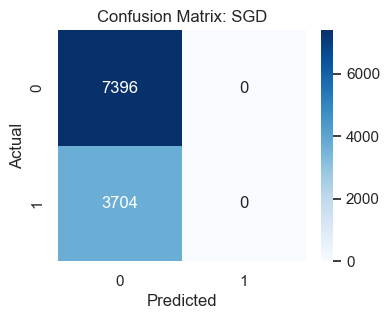


MiniBatch Test metrics: Accuracy=0.6663, Precision=0.0000, Recall=0.0000, F1=0.0000


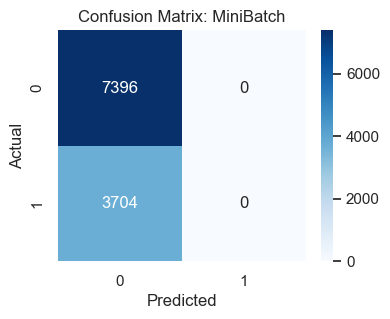


MiniBatch_L2 Test metrics: Accuracy=0.6663, Precision=0.0000, Recall=0.0000, F1=0.0000


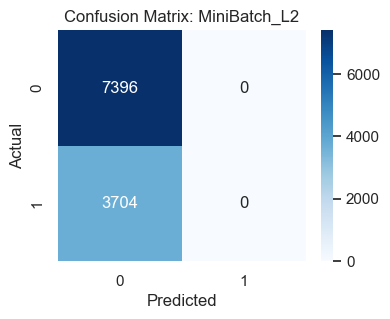

,Model,Accuracy,Precision,Recall,F1
0,SGD,0.666306,0.0,0.0,0.0
1,MiniBatch,0.666306,0.0,0.0,0.0
2,MiniBatch_L2,0.666306,0.0,0.0,0.0


In [35]:
# Cell 10: Evaluation on test set
eval_rows = []
for name, model in trained_models.items():
    y_proba = model.predict_proba(X_test)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    eval_rows.append([name, acc, prec, rec, f1])
    print(f"\n{name} Test metrics: Accuracy={acc:.4f}, Precision={prec:.4f}, Recall={rec:.4f}, F1={f1:.4f}")
    # confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix: {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

eval_df = pd.DataFrame(eval_rows, columns=["Model","Accuracy","Precision","Recall","F1"])
eval_df


In [36]:
# Cell 11: Diagnostics - check class balance and predictions distribution
print("Train label distribution:", np.unique(y_train, return_counts=True))
for name, model in trained_models.items():
    y_pred_train = model.predict(X_train)
    unique, counts = np.unique(y_pred_train, return_counts=True)
    print(f"{name} - train prediction distribution: {dict(zip(unique.astype(int), counts))}")


Train label distribution: (array([0, 1]), array([22190, 11110], dtype=int64))
SGD - train prediction distribution: {0: 33300}
MiniBatch - train prediction distribution: {0: 33300}
MiniBatch_L2 - train prediction distribution: {0: 33300}


In [38]:
# Cell 12: Save best model weights (optional) and conclude
# Pick best by F1
best_name = eval_df.sort_values('F1', ascending=False)['Model'].iloc[0]
print("Best model by F1:", best_name)
# example: access weights:
best_model = trained_models[best_name]
print("Bias:", best_model.b, "weights shape:", best_model.w.shape)

from IPython.display import Markdown
Markdown("""
### Conclusions (auto-generated)
- Implemented logistic regression **from scratch** with SGD and mini-batch.
- Implemented L2 regularization.
- Early stopping based on validation loss was used.
- Evaluation table above summarizes Accuracy/Precision/Recall/F1 on the test set.
- If the model predicts only one class (Precision/Recall/F1 zero), check:
  1. class imbalance (printed above),
  2. feature preprocessing (constant columns removed/normalized),
  3. learning rate & epochs.
""")


Best model by F1: SGD
Bias: -0.6155541241168909 weights shape: (2, 1)



### Conclusions (auto-generated)
- Implemented logistic regression **from scratch** with SGD and mini-batch.
- Implemented L2 regularization.
- Early stopping based on validation loss was used.
- Evaluation table above summarizes Accuracy/Precision/Recall/F1 on the test set.
- If the model predicts only one class (Precision/Recall/F1 zero), check:
  1. class imbalance (printed above),
  2. feature preprocessing (constant columns removed/normalized),
  3. learning rate & epochs.


# Висновки щодо навчання

SGD показує значні коливання втрат (loss) між епохами — це очікувано для чистого SGD без усереднення, оскільки він оновлює ваги після кожного прикладу і сильно залежить від шуму даних.

Val loss ≈ 0.659 → модель не навчилася краще за базову.
Accuracy ≈ 0.666 — це дуже близько до частки домінантного класу (≈ 2/3).
Precision, Recall, F1 = 0 → модель передбачає лише один клас .

Mini-Batch Gradient Descent і Regularized L2 Mini-Batch стабільніші (криві loss пласкі, без шуму).
Train/Val loss ≈ 0.636 — трохи нижче, ніж у SGD, тобто тренування ефективніше.
Але метрики (Accuracy ≈ 0.666, інші = 0) залишилися такими ж, бо модель так само передбачає лише клас 0.

## Інтерпретація

Модель не навчилася відрізняти класи.
Ймовірно, клас 1 рідкісний або погано відділяється за ознаками.
Loss знизився, але decision boundary не змінився суттєво — ваги залишилися малі або зміщення (bias) спрямовує модель у сторону 0.
Регуляризація (L2) не дала змін, бо й так немає переобучення, а лише брак сигналу для навчання.

## Що варто зробити далі

Перевірити баланс класів — якщо 2/3 зразків = 0, треба збалансувати (undersampling / oversampling).
Масштабувати та очистити ознаки — можливо, у набір потрапили нерелевантні або надто різномасштабні дані.
Додати нелінійність (наприклад, Logistic Regression з поліноміальними ознаками або нейронну мережу) — можливо, залежність не є лінійною.